# EDA — bruit.csv
Score de Vivabilité · Mesures acoustiques Paris

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parents[0]
FILE = BASE_DIR / 'brute' / 'score_de_vivabilité' / 'bruit.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (16, 35)
Colonnes : ['Année', 'Périphérique Auteuil - Lden dB(A)', 'Périphérique Auteuil - Ln dB(A)', 'Périphérique Vincennes - Lden dB(A)', 'Périphérique Vincennes - Ln dB(A)', 'lden_bruit routier_malesherbes', 'ln_bruit routier_malesherbes', '88 rue de Courcelles (enrob-clas)  - Lden dB(A)', '88 rue de Courcelles (enrob-clas) - Ln dB(A)', '62 rue de Courcelles (enrob-pho) - Lden dB(A)', '62 rue de Courcelles (enrob-pho) - Ln dB(A)', '74 rue Pierre Soulié - Lden dB(A)', '74 rue Pierre Soulié - Ln dB(A)', '21 boulevard Poissonière - Lden dB(A)', '21 boulevard Poissonière - Ln dB(A)', '102 boulevard de Sébastopol - Lden dB(A)', '102 boulevard de Sébastopol - Ln dB(A)', 'lden_bruit routier_anatolefrance', 'ln_bruit routier_anatolefrance', '88 rue de Rivoli - Lden dB(A)', '88 rue de Rivoli - Ln dB(A)', 'lden_bruit routier_gesvres', 'ln_bruit routier_gesvres', '246 boulevard Saint-Germain - Lden  dB(A)', '246 boulevard Saint-Germain - Ln  dB(A)', '4 place St Michel - Lden dB(A)', '

,Année,Périphérique Auteuil - Lden dB(A),Périphérique Auteuil - Ln dB(A),Périphérique Vincennes - Lden dB(A),Périphérique Vincennes - Ln dB(A),lden_bruit routier_malesherbes,ln_bruit routier_malesherbes,88 rue de Courcelles (enrob-clas) - Lden dB(A),88 rue de Courcelles (enrob-clas) - Ln dB(A),62 rue de Courcelles (enrob-pho) - Lden dB(A),...,4 place St Michel - Lden dB(A),4 place St Michel - Ln dB(A),lden_bruit routier_bastille,ln_bruit routier_bastille,37 rue Frémicourt (enrob-pho) - Lden dB(A),37 rue Frémicourt (enrob-pho) - Ln dB(A),13 rue Frémicourt (enrob-clas) - Lden dB(A),13 rue Frémicourt (enrob-clas) - Ln dB(A),214 rue Lecourbe - Lden dB(A),214 rue Lecourbe - Ln dB(A)
0,2015,87.1,79.7,83.4,76.6,NaN,NaN,NaN,NaN,NaN,...,74.6,67.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,75.3,67.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,83.5,76.2,85.8,79.3,74.0,66.5,71.8,63.9,71.5,...,72.0,64.3,73.8,66.2,66.2,57.9,70.2,62.2,72.0,64.4
3,2022,83.3,76.4,85.8,79.3,NaN,NaN,72.1,64.4,71.6,...,72.4,64.9,74.5,66.9,70.4,62.1,70.0,62.0,71.9,64.1
4,2025,82.2,74.8,84.1,77.5,73.9,66.4,72.4,65.1,71.8,...,72.5,65.2,74.0,66.6,71.3,63.1,70.6,62.7,71.9,64.2


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 35 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Année                                            16 non-null     int64  
 1   Périphérique Auteuil - Lden dB(A)                14 non-null     float64
 2   Périphérique Auteuil - Ln dB(A)                  14 non-null     float64
 3   Périphérique Vincennes - Lden dB(A)              14 non-null     float64
 4   Périphérique Vincennes - Ln dB(A)                14 non-null     float64
 5   lden_bruit routier_malesherbes                   2 non-null      float64
 6   ln_bruit routier_malesherbes                     2 non-null      float64
 7   88 rue de Courcelles (enrob-clas)  - Lden dB(A)  8 non-null      float64
 8   88 rue de Courcelles (enrob-clas) - Ln dB(A)     8 non-null      float64
 9   62 rue de Courcelles (enrob-pho) - Lden dB(A)

In [4]:
df.describe(include='all')

,Année,Périphérique Auteuil - Lden dB(A),Périphérique Auteuil - Ln dB(A),Périphérique Vincennes - Lden dB(A),Périphérique Vincennes - Ln dB(A),lden_bruit routier_malesherbes,ln_bruit routier_malesherbes,88 rue de Courcelles (enrob-clas) - Lden dB(A),88 rue de Courcelles (enrob-clas) - Ln dB(A),62 rue de Courcelles (enrob-pho) - Lden dB(A),...,4 place St Michel - Lden dB(A),4 place St Michel - Ln dB(A),lden_bruit routier_bastille,ln_bruit routier_bastille,37 rue Frémicourt (enrob-pho) - Lden dB(A),37 rue Frémicourt (enrob-pho) - Ln dB(A),13 rue Frémicourt (enrob-clas) - Lden dB(A),13 rue Frémicourt (enrob-clas) - Ln dB(A),214 rue Lecourbe - Lden dB(A),214 rue Lecourbe - Ln dB(A)
count,16.000000,14.000000,14.000000,14.000000,14.000000,2.000000,2.000000,8.000000,8.000000,8.000000,...,16.000000,16.000000,8.000000,8.000000,7.000000,7.000000,8.00000,8.000000,8.00,8.000000
mean,2017.500000,85.535714,78.242857,84.857143,78.235714,73.950000,66.450000,72.225000,64.387500,71.725000,...,73.925000,66.468750,74.262500,66.587500,69.971429,61.557143,70.20000,62.000000,71.95,64.225000
std,4.760952,2.024696,2.022076,1.085367,1.161966,0.070711,0.070711,0.667083,0.844203,0.544453,...,1.346848,1.580599,1.365846,1.608404,1.866114,1.931198,0.48107,0.623355,0.60,0.654108
min,2010.000000,82.200000,74.800000,83.100000,76.400000,73.900000,66.400000,71.500000,63.200000,70.600000,...,72.000000,64.300000,72.200000,64.100000,66.200000,57.900000,69.50000,61.100000,71.20,63.300000
25%,2013.750000,83.575000,76.250000,84.125000,77.425000,73.925000,66.425000,71.750000,63.775000,71.575000,...,72.575000,65.125000,73.650000,65.950000,69.700000,60.900000,69.92500,61.650000,71.55,63.975000
50%,2017.500000,86.300000,79.100000,84.900000,78.350000,73.950000,66.450000,72.050000,64.400000,71.750000,...,74.000000,66.700000,74.200000,66.650000,70.400000,62.100000,70.20000,61.900000,71.90,64.200000
75%,2021.250000,87.175000,79.925000,85.800000,79.300000,73.975000,66.475000,72.575000,65.150000,72.075000,...,74.675000,67.200000,74.675000,67.025000,70.900000,62.650000,70.45000,62.325000,72.15,64.425000
max,2025.000000,88.000000,80.600000,86.200000,79.700000,74.000000,66.500000,73.300000,65.400000,72.300000,...,76.800000,70.100000,76.800000,69.600000,72.000000,63.800000,71.00000,63.000000,73.00,65.500000


## 3. Valeurs manquantes — critique pour ce dataset

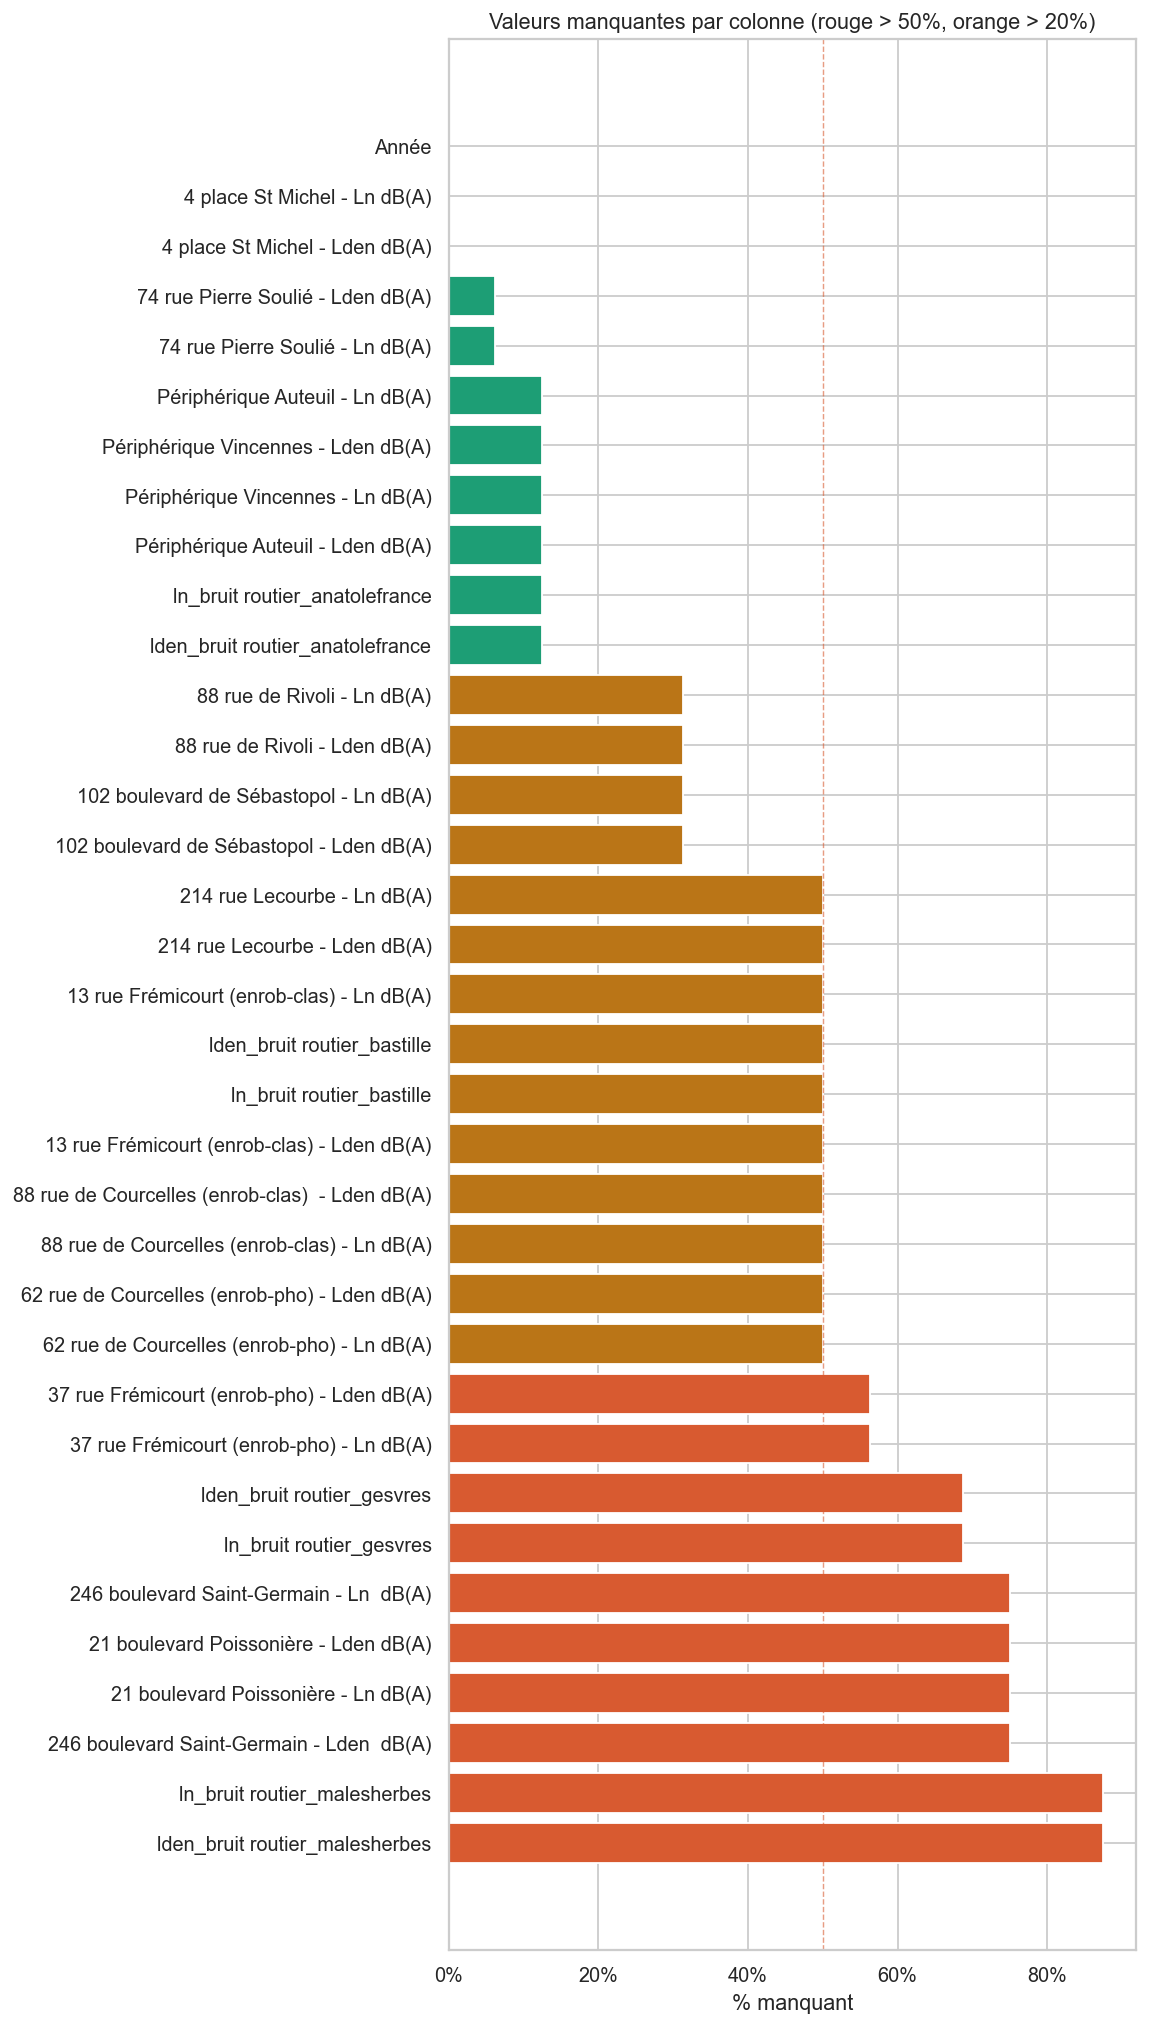

,% manquant
lden_bruit routier_malesherbes,87.50
ln_bruit routier_malesherbes,87.50
246 boulevard Saint-Germain - Lden dB(A),75.00
21 boulevard Poissonière - Ln dB(A),75.00
21 boulevard Poissonière - Lden dB(A),75.00
246 boulevard Saint-Germain - Ln dB(A),75.00
ln_bruit routier_gesvres,68.75
lden_bruit routier_gesvres,68.75
37 rue Frémicourt (enrob-pho) - Ln dB(A),56.25
37 rue Frémicourt (enrob-pho) - Lden dB(A),56.25


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Structure temporelle

In [7]:
annee_col = [c for c in df.columns if 'ann' in c.lower() or 'year' in c.lower()][0]
print(f'Colonne année : {annee_col}')
print(f'Plage         : {df[annee_col].min()} → {df[annee_col].max()}')
print(f'Nb années     : {df[annee_col].nunique()}')
print(f'Années        : {sorted(df[annee_col].tolist())}')

Colonne année : Année
Plage         : 2010 → 2025
Nb années     : 16
Années        : [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 6. Séparation colonnes Lden / Ln

In [8]:
lden_cols = [c for c in df.columns if 'lden' in c.lower()]
ln_cols   = [c for c in df.columns if ('_ln_' in c.lower() or ' ln ' in c or c.lower().endswith('ln db(a)')) and c not in lden_cols]

print(f'Colonnes Lden : {len(lden_cols)}')
print(f'Colonnes Ln   : {len(ln_cols)}')

lden_ok = [c for c in lden_cols if df[c].isnull().mean() < 0.6]
ln_ok   = [c for c in ln_cols   if df[c].isnull().mean() < 0.6]
print(f'\nLden exploitables (< 60% NaN) : {len(lden_ok)}')
print(f'Ln   exploitables (< 60% NaN) : {len(ln_ok)}')

Colonnes Lden : 17
Colonnes Ln   : 12

Lden exploitables (< 60% NaN) : 13
Ln   exploitables (< 60% NaN) : 11


## 7. Évolution temporelle des capteurs Lden exploitables

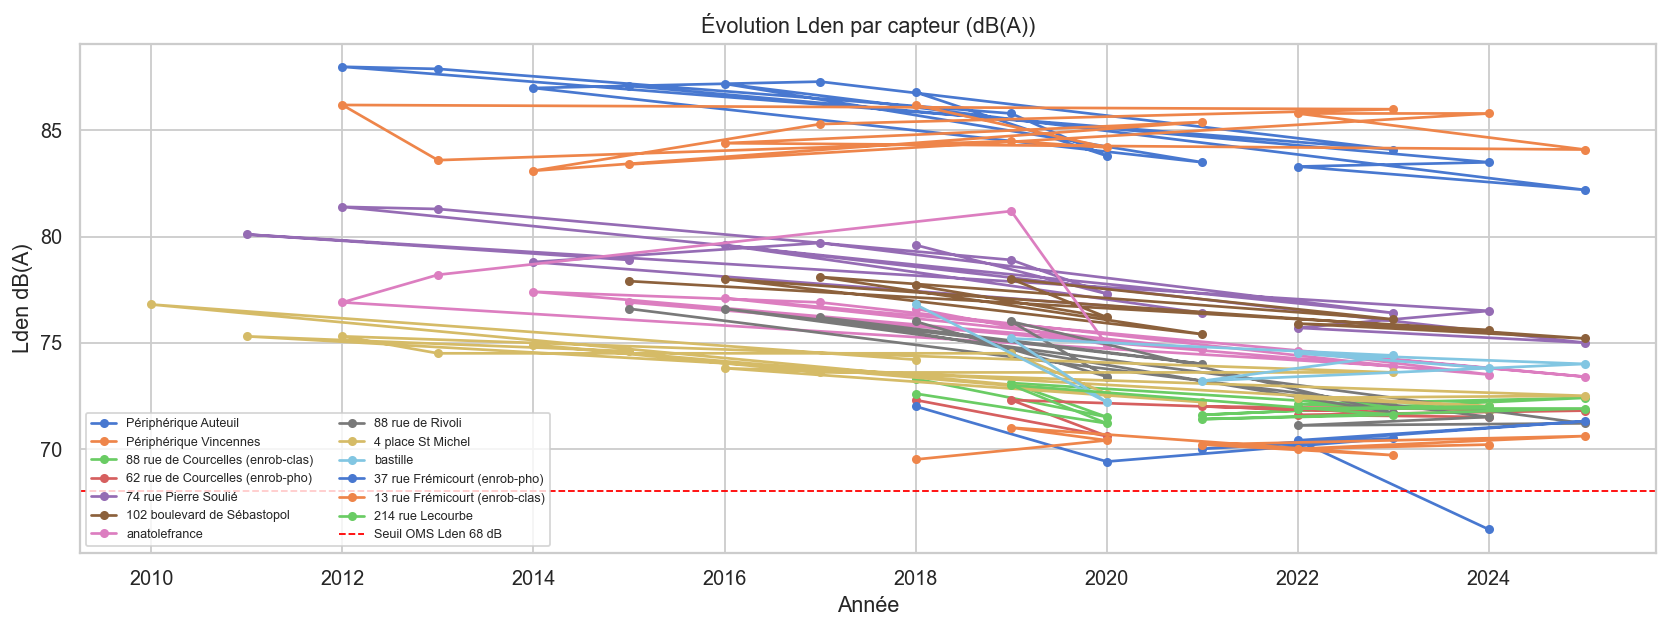

In [9]:
if lden_ok:
    fig, ax = plt.subplots(figsize=(13, 5))
    for col in lden_ok:
        serie = df[[annee_col, col]].dropna()
        label = col.replace(' - Lden dB(A)', '').replace(' - Lden  dB(A)', '').replace('lden_bruit routier_', '').strip()
        ax.plot(serie[annee_col], serie[col], marker='o', markersize=4, linewidth=1.5, label=label)
    ax.axhline(68, color='red', linestyle='--', linewidth=1, label='Seuil OMS Lden 68 dB')
    ax.set_title('Évolution Lden par capteur (dB(A))')
    ax.set_xlabel('Année'); ax.set_ylabel('Lden dB(A)')
    ax.legend(fontsize=7, loc='lower left', ncol=2)
    plt.tight_layout()
    plt.show()

## 8. Distribution des niveaux sonores (boxplots)

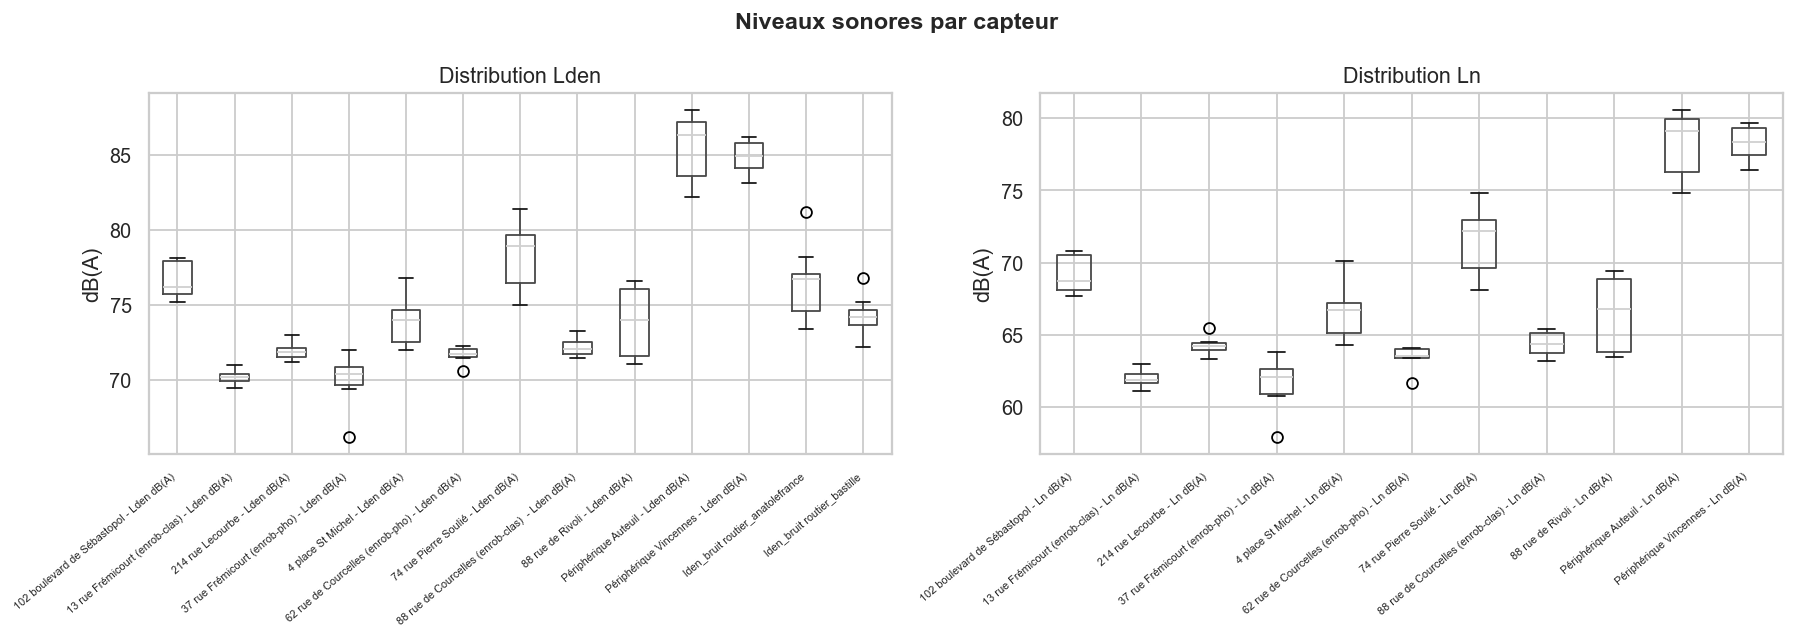

In [10]:
all_ok = lden_ok + ln_ok
if all_ok:
    plot_data = df[all_ok].melt(var_name='Capteur', value_name='dB(A)').dropna()
    plot_data['Type'] = plot_data['Capteur'].apply(lambda x: 'Lden' if 'lden' in x.lower() else 'Ln')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, typ in zip(axes, ['Lden', 'Ln']):
        sub = plot_data[plot_data['Type'] == typ]
        if not sub.empty:
            sub.boxplot(column='dB(A)', by='Capteur', ax=ax)
            ax.set_title(f'Distribution {typ}')
            ax.set_ylabel('dB(A)'); ax.set_xlabel('')
            plt.sca(ax); plt.xticks(rotation=40, ha='right', fontsize=6)
    plt.suptitle('Niveaux sonores par capteur', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Couverture temporelle par capteur

In [11]:
num_cols = df.select_dtypes(include='number').columns.drop(annee_col)
coverage = pd.DataFrame({
    'capteur'         : num_cols,
    'n_mesures'       : [df[c].notna().sum() for c in num_cols],
    '% couvert'       : [(df[c].notna().mean() * 100).round(1) for c in num_cols],
    'première_année'  : [df.loc[df[c].notna(), annee_col].min() if df[c].notna().any() else None for c in num_cols],
    'dernière_année'  : [df.loc[df[c].notna(), annee_col].max() if df[c].notna().any() else None for c in num_cols],
    'moy_dB'          : [df[c].mean().round(2) for c in num_cols],
}).sort_values('% couvert', ascending=False)
display(coverage)

,capteur,n_mesures,% couvert,première_année,dernière_année,moy_dB
25,4 place St Michel - Ln dB(A),16,100.0,2010,2025,66.47
24,4 place St Michel - Lden dB(A),16,100.0,2010,2025,73.92
10,74 rue Pierre Soulié - Lden dB(A),15,93.8,2011,2025,78.37
11,74 rue Pierre Soulié - Ln dB(A),15,93.8,2011,2025,71.62
0,Périphérique Auteuil - Lden dB(A),14,87.5,2012,2025,85.54
1,Périphérique Auteuil - Ln dB(A),14,87.5,2012,2025,78.24
16,lden_bruit routier_anatolefrance,14,87.5,2012,2025,76.16
17,ln_bruit routier_anatolefrance,14,87.5,2012,2025,69.06
2,Périphérique Vincennes - Lden dB(A),14,87.5,2012,2025,84.86
3,Périphérique Vincennes - Ln dB(A),14,87.5,2012,2025,78.24


## 10. Résumé + plan Silver

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — bruit.csv')
print('=' * 55)
print(f'  Lignes (années)      : {len(df)}')
print(f'  Colonnes (capteurs)  : {len(df.columns) - 1}  (+1 col Année)')
print(f'  Plage temporelle     : {df[annee_col].min()} → {df[annee_col].max()}')
print(f'  Colonnes Lden        : {len(lden_cols)}')
print(f'  Colonnes Ln          : {len(ln_cols)}')
cols_trop_vides = (df.isnull().mean() > 0.6).sum()
print(f'  Capteurs > 60% NaN   : {cols_trop_vides}  ← à exclure en Silver')
print(f'  Capteurs exploitables: {len(all_ok)}')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Exclure capteurs avec > 60% de NaN')
print('  → Pivoter en format long : (année, capteur, type_Lden_Ln, valeur_dB)')
print('  → Normaliser les noms de capteurs (supprimer suffixes dB(A))')
print('  → Comparer Lden moyen annuel au seuil OMS 68 dB')
print('  → Export Parquet pour Gold scoring vivabilité')

RÉSUMÉ EDA — bruit.csv
  Lignes (années)      : 16
  Colonnes (capteurs)  : 34  (+1 col Année)
  Plage temporelle     : 2010 → 2025
  Colonnes Lden        : 17
  Colonnes Ln          : 12
  Capteurs > 60% NaN   : 8  ← à exclure en Silver
  Capteurs exploitables: 24

ACTIONS SILVER REQUISES :
  → Exclure capteurs avec > 60% de NaN
  → Pivoter en format long : (année, capteur, type_Lden_Ln, valeur_dB)
  → Normaliser les noms de capteurs (supprimer suffixes dB(A))
  → Comparer Lden moyen annuel au seuil OMS 68 dB
  → Export Parquet pour Gold scoring vivabilité
